In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress

In [4]:
import os
print(os.getcwd())

c:\Users\bindu\OneDrive\Desktop\bluestock_mf_capstone\notebooks


In [6]:
import pandas as pd

nav = pd.read_csv("../data/raw/02_nav_history.csv")

In [7]:
nav.head()


,amfi_code,date,nav
0,119551,2022-01-03,54.3856
1,119551,2022-01-04,54.3474
2,119551,2022-01-05,54.6869
3,119551,2022-01-06,55.4550
4,119551,2022-01-07,55.3692


In [8]:
nav['amfi_code'].nunique()

40

In [9]:
nav['date'] = pd.to_datetime(nav['date'])

In [10]:
nav = nav.sort_values(['amfi_code', 'date'])

In [12]:
nav['daily_return'] = nav.groupby('amfi_code')['nav'].pct_change()

In [13]:
nav.head()

,amfi_code,date,nav,daily_return
5750,100016,2022-01-03,520.4608,NaN
5751,100016,2022-01-04,515.0971,-0.010306
5752,100016,2022-01-05,521.7239,0.012865
5753,100016,2022-01-06,515.7880,-0.011377
5754,100016,2022-01-07,515.1639,-0.001210


In [14]:
nav['daily_return'].describe()

count    45960.000000
mean         0.000631
std          0.010290
min         -0.058102
25%         -0.005042
50%          0.000340
75%          0.006324
max          0.064713
Name: daily_return, dtype: float64

In [15]:
nav['date'].min(), nav['date'].max()

(Timestamp('2022-01-03 00:00:00'), Timestamp('2026-05-29 00:00:00'))

In [16]:
nav.groupby('amfi_code').size().head()

amfi_code
100016    1150
100025    1150
100033    1150
101206    1150
101207    1150
dtype: int64

In [17]:
def cagr(start_nav, end_nav, years):
    return ((end_nav / start_nav) ** (1 / years)) - 1

In [18]:
cagr_1y = []

for fund in nav['amfi_code'].unique():

    temp = nav[nav['amfi_code'] == fund]

    end_nav = temp['nav'].iloc[-1]
    start_nav = temp['nav'].iloc[-252]

    value = cagr(start_nav, end_nav, 1)

    cagr_1y.append([fund, value])

In [19]:
cagr_1y_df = pd.DataFrame(
    cagr_1y,
    columns=['amfi_code', 'CAGR_1Y']
)

cagr_1y_df.head()

,amfi_code,CAGR_1Y
0,100016,-0.033055
1,100025,0.025018
2,100033,0.477346
3,101206,0.450939
4,101207,-0.242421


In [20]:
cagr_3y = []

for fund in nav['amfi_code'].unique():

    temp = nav[nav['amfi_code'] == fund]

    end_nav = temp['nav'].iloc[-1]
    start_nav = temp['nav'].iloc[-756]

    value = cagr(start_nav, end_nav, 3)

    cagr_3y.append([fund, value])

In [21]:
cagr_3y_df = pd.DataFrame(
    cagr_3y,
    columns=['amfi_code', 'CAGR_3Y']
)

cagr_3y_df.head()

,amfi_code,CAGR_3Y
0,100016,-0.000316
1,100025,0.046143
2,100033,0.336292
3,101206,0.325286
4,101207,-0.026965


In [22]:
rf = 0.065

In [23]:
def sharpe_ratio(returns):

    returns = returns.dropna()

    excess_return = returns.mean() - (rf / 252)

    return (excess_return / returns.std()) * np.sqrt(252)

In [24]:
sharpe = nav.groupby(
    'amfi_code'
)['daily_return'].apply(sharpe_ratio)

In [25]:
sharpe = sharpe.reset_index()

sharpe.columns = [
    'amfi_code',
    'Sharpe_Ratio'
]

sharpe.head()

,amfi_code,Sharpe_Ratio
0,100016,-0.201517
1,100025,-0.567095
2,100033,1.093699
3,101206,1.027213
4,101207,0.162661


In [26]:
def sortino_ratio(returns):

    returns = returns.dropna()

    downside_returns = returns[returns < 0]

    downside_std = downside_returns.std()

    excess_return = returns.mean() - (rf / 252)

    return (excess_return / downside_std) * np.sqrt(252)

In [27]:
sortino = nav.groupby(
    'amfi_code'
)['daily_return'].apply(sortino_ratio)

In [28]:
sortino = sortino.reset_index()

sortino.columns = [
    'amfi_code',
    'Sortino_Ratio'
]

sortino.head()

,amfi_code,Sortino_Ratio
0,100016,-0.351047
1,100025,-0.941821
2,100033,1.829134
3,101206,1.799563
4,101207,0.276644


In [29]:
sortino = sortino.sort_values(
    'Sortino_Ratio',
    ascending=False
)

In [30]:
sortino.head(10)

,amfi_code,Sortino_Ratio
34,148567,2.385644
30,120843,2.364320
36,148569,2.146914
19,119551,2.140267
25,120505,2.029353
38,149323,1.875101
9,118632,1.850133
2,100033,1.829134
24,120504,1.805294
3,101206,1.799563


In [31]:
benchmark = pd.read_csv("../data/raw/10_benchmark_indices.csv")

benchmark.head()

,date,index_name,close_value
0,2022-01-03,NIFTY50,17492.79
1,2022-01-04,NIFTY50,17689.64
2,2022-01-05,NIFTY50,17835.05
3,2022-01-06,NIFTY50,17878.51
4,2022-01-07,NIFTY50,17759.15


In [32]:
benchmark.columns

Index(['date', 'index_name', 'close_value'], dtype='str')

In [33]:
benchmark['index_name'].unique()

<StringArray>
[        'NIFTY50',        'NIFTY100', 'NIFTY_MIDCAP150',    'BSE_SMALLCAP',
        'NIFTY500',   'CRISIL_LIQUID',     'CRISIL_GILT']
Length: 7, dtype: str

In [34]:
benchmark.head()

,date,index_name,close_value
0,2022-01-03,NIFTY50,17492.79
1,2022-01-04,NIFTY50,17689.64
2,2022-01-05,NIFTY50,17835.05
3,2022-01-06,NIFTY50,17878.51
4,2022-01-07,NIFTY50,17759.15


In [35]:
benchmark['index_name'].unique()

<StringArray>
[        'NIFTY50',        'NIFTY100', 'NIFTY_MIDCAP150',    'BSE_SMALLCAP',
        'NIFTY500',   'CRISIL_LIQUID',     'CRISIL_GILT']
Length: 7, dtype: str

In [36]:
nifty100 = benchmark[
    benchmark['index_name'] == 'NIFTY100'
].copy()

In [37]:
nifty100.head()

,date,index_name,close_value
1150,2022-01-03,NIFTY100,17778.24
1151,2022-01-04,NIFTY100,17537.52
1152,2022-01-05,NIFTY100,17607.73
1153,2022-01-06,NIFTY100,17556.05
1154,2022-01-07,NIFTY100,17664.02


In [38]:
from scipy.stats import linregress

In [39]:
alpha_beta = []

In [40]:
for fund in nav['amfi_code'].unique():

    fund_data = nav[
        nav['amfi_code'] == fund
    ][['date', 'daily_return']]

    merged = pd.merge(
        fund_data,
        nifty100[['date', 'daily_return']],
        on='date',
        suffixes=('_fund', '_market')
    )

    merged = merged.dropna()

    result = linregress(
        merged['daily_return_market'],
        merged['daily_return_fund']
    )

    alpha = result.intercept * 252
    beta = result.slope

    alpha_beta.append(
        [fund, alpha, beta]
    )

KeyError: "['daily_return'] not in index"

In [41]:
nifty100.columns

Index(['date', 'index_name', 'close_value'], dtype='str')

In [42]:
nifty100['daily_return'] = nifty100['close_value'].pct_change()

In [43]:
nifty100.head()

,date,index_name,close_value,daily_return
1150,2022-01-03,NIFTY100,17778.24,NaN
1151,2022-01-04,NIFTY100,17537.52,-0.013540
1152,2022-01-05,NIFTY100,17607.73,0.004003
1153,2022-01-06,NIFTY100,17556.05,-0.002935
1154,2022-01-07,NIFTY100,17664.02,0.006150


In [44]:
alpha_beta = []

for fund in nav['amfi_code'].unique():

    fund_data = nav[
        nav['amfi_code'] == fund
    ][['date', 'daily_return']]

    merged = pd.merge(
        fund_data,
        nifty100[['date', 'daily_return']],
        on='date',
        suffixes=('_fund', '_market')
    )

    merged = merged.dropna()

    result = linregress(
        merged['daily_return_market'],
        merged['daily_return_fund']
    )

    alpha = result.intercept * 252
    beta = result.slope

    alpha_beta.append([fund, alpha, beta])

ValueError: You are trying to merge on datetime64[us] and str columns for key 'date'. If you wish to proceed you should use pd.concat

In [45]:
nifty100['date'] = pd.to_datetime(nifty100['date'])

In [46]:
print(nav['date'].dtype)
print(nifty100['date'].dtype)

datetime64[us]
datetime64[us]


In [47]:
print(nav['date'].dtype)
print(nifty100['date'].dtype)

datetime64[us]
datetime64[us]


In [48]:
fund = nav['amfi_code'].unique()[0]

fund_data = nav[
    nav['amfi_code'] == fund
][['date', 'daily_return']]

merged = pd.merge(
    fund_data,
    nifty100[['date', 'daily_return']],
    on='date',
    suffixes=('_fund', '_market')
)

merged.head()

,date,daily_return_fund,daily_return_market
0,2022-01-03,NaN,NaN
1,2022-01-04,-0.010306,-0.013540
2,2022-01-05,0.012865,0.004003
3,2022-01-06,-0.011377,-0.002935
4,2022-01-07,-0.001210,0.006150


In [49]:
merged.shape

(1150, 3)

In [50]:
alpha_beta = []

for fund in nav['amfi_code'].unique():

    fund_data = nav[
        nav['amfi_code'] == fund
    ][['date', 'daily_return']]

    merged = pd.merge(
        fund_data,
        nifty100[['date', 'daily_return']],
        on='date',
        suffixes=('_fund', '_market')
    )

    merged = merged.dropna()

    result = linregress(
        merged['daily_return_market'],
        merged['daily_return_fund']
    )

    alpha = result.intercept * 252
    beta = result.slope

    alpha_beta.append([fund, alpha, beta])

In [51]:
alpha_beta_df = pd.DataFrame(
    alpha_beta,
    columns=[
        'amfi_code',
        'Alpha',
        'Beta'
    ]
)

alpha_beta_df.head()

,amfi_code,Alpha,Beta
0,100016,0.037476,-0.058268
1,100025,0.042818,0.001158
2,100033,0.271954,0.005104
3,101206,0.213998,0.021086
4,101207,0.108971,-0.065289


In [52]:
alpha_beta_df.to_csv(
    "../outputs/alpha_beta.csv",
    index=False
)

OSError: Cannot save file into a non-existent directory: '..\outputs'

In [53]:
import os

os.makedirs("../outputs", exist_ok=True)

In [54]:
import os
print(os.getcwd())

c:\Users\bindu\OneDrive\Desktop\bluestock_mf_capstone\notebooks


In [55]:
import os

os.makedirs("../outputs", exist_ok=True)


In [56]:
os.listdir("..")

['.git',
 '.gitignore',
 'bluestock_mf.db',
 'check_perf.py',
 'check_txn.py',
 'dashboard',
 'data',
 'nav_history_cleaned.csv',
 'notebooks',
 'outputs',
 'performance_cleaned.csv',
 'README.md',
 'reports',
 'requirements.txt',
 'scripts',
 'sql',
 'transactions_cleaned.csv']

In [57]:
alpha_beta_df.to_csv(
    "../outputs/alpha_beta.csv",
    index=False
)

In [58]:
def max_drawdown(nav_series):

    running_max = nav_series.cummax()

    drawdown = (
        nav_series / running_max
    ) - 1

    return drawdown.min()

In [59]:
mdd = nav.groupby(
    'amfi_code'
)['nav'].apply(max_drawdown)

mdd = mdd.reset_index()

mdd.columns = [
    'amfi_code',
    'Max_Drawdown'
]

mdd.head()

,amfi_code,Max_Drawdown
0,100016,-0.247344
1,100025,-0.043083
2,100033,-0.162172
3,101206,-0.112916
4,101207,-0.354469


In [60]:
mdd.sort_values(
    'Max_Drawdown'
).head()

,amfi_code,Max_Drawdown
22,119599,-0.525742
17,119095,-0.516778
4,101207,-0.354469
39,149324,-0.311719
21,119598,-0.287060


In [61]:
mdd.head()

,amfi_code,Max_Drawdown
0,100016,-0.247344
1,100025,-0.043083
2,100033,-0.162172
3,101206,-0.112916
4,101207,-0.354469


In [62]:
mdd.sort_values('Max_Drawdown').head()

,amfi_code,Max_Drawdown
22,119599,-0.525742
17,119095,-0.516778
4,101207,-0.354469
39,149324,-0.311719
21,119598,-0.287060


In [63]:
import os

for root, dirs, files in os.walk("../data"):
    for file in files:
        print(file)

nav_history_cleaned.csv
performance_cleaned.csv
transactions_cleaned.csv
01_fund_master.csv
02_nav_history.csv
03_aum_by_fund_house.csv
04_monthly_sip_inflows.csv
05_category_inflows.csv
06_industry_folio_count.csv
07_scheme_performance.csv
08_investor_transactions.csv
09_portfolio_holdings.csv
10_benchmark_indices.csv
HDFC_Top100_live_nav.csv


In [65]:
fund_master = pd.read_csv("../data/raw/01_fund_master.csv")

In [66]:
fund_master.columns

Index(['amfi_code', 'fund_house', 'scheme_name', 'category', 'sub_category',
       'plan', 'launch_date', 'benchmark', 'expense_ratio_pct',
       'exit_load_pct', 'min_sip_amount', 'min_lumpsum_amount', 'fund_manager',
       'risk_category', 'sebi_category_code'],
      dtype='str')

In [67]:
fund_master.head()

,amfi_code,fund_house,scheme_name,category,sub_category,plan,launch_date,benchmark,expense_ratio_pct,exit_load_pct,min_sip_amount,min_lumpsum_amount,fund_manager,risk_category,sebi_category_code
0,119551,SBI Mutual Fund,SBI Bluechip Fund - Regular Plan - Growth,Equity,Large Cap,Regular,2006-02-14,NIFTY 100 TRI,1.54,1.0,500,1000,Sohini Andani,Moderate,EC01
1,119552,SBI Mutual Fund,SBI Bluechip Fund - Direct Plan - Growth,Equity,Large Cap,Direct,2013-01-01,NIFTY 100 TRI,0.66,1.0,500,1000,Sohini Andani,Moderate,EC01
2,119598,SBI Mutual Fund,SBI Small Cap Fund - Regular Plan - Growth,Equity,Small Cap,Regular,2009-09-09,BSE 250 SmallCap TRI,1.43,1.0,500,1000,R. Srinivasan,Very High,EC03
3,119599,SBI Mutual Fund,SBI Small Cap Fund - Direct Plan - Growth,Equity,Small Cap,Direct,2013-01-01,BSE 250 SmallCap TRI,0.72,1.0,500,1000,R. Srinivasan,Very High,EC03
4,119120,SBI Mutual Fund,SBI Magnum Gilt Fund - Regular Plan - Growth,Debt,Gilt,Regular,2000-12-30,CRISIL Dynamic Gilt Index,0.77,0.0,500,1000,Dinesh Ahuja,Low,DC02


In [68]:
expense = fund_master[
    ['amfi_code', 'expense_ratio_pct']
].copy()

expense.head()

,amfi_code,expense_ratio_pct
0,119551,1.54
1,119552,0.66
2,119598,1.43
3,119599,0.72
4,119120,0.77


In [70]:
%whos

Variable        Type                Data/Info
---------------------------------------------
alpha           float64             0.3005787817097677
alpha_beta      list                n=40
alpha_beta_df   DataFrame           Shape: (40, 3)
benchmark       DataFrame           Shape: (8050, 3)
beta            float64             0.011455159960520708
cagr            function            <function cagr at 0x00000136E706B9C0>
cagr_1y         list                n=40
cagr_1y_df      DataFrame           Shape: (40, 2)
cagr_3y         list                n=40
cagr_3y_df      DataFrame           Shape: (40, 2)
dirs            list                n=0
end_nav         float64             279.7511
expense         DataFrame           Shape: (40, 2)
file            str                 HDFC_Top100_live_nav.csv
files           list                n=11
fund            int64               149324
fund_data       DataFrame           Shape: (1150, 2)
fund_master     DataFrame           Shape: (40, 15)
linregr

In [71]:
cagr_table = cagr_1y_df.merge(
    cagr_3y_df,
    on='amfi_code'
)

cagr_table.head()

,amfi_code,CAGR_1Y,CAGR_3Y
0,100016,-0.033055,-0.000316
1,100025,0.025018,0.046143
2,100033,0.477346,0.336292
3,101206,0.450939,0.325286
4,101207,-0.242421,-0.026965


In [72]:
cagr_table['cagr_rank'] = cagr_table['CAGR_3Y'].rank(
    ascending=False
)

In [73]:
sharpe['sharpe_rank'] = sharpe['Sharpe_Ratio'].rank(
    ascending=False
)

In [74]:
alpha_beta_df['alpha_rank'] = alpha_beta_df['Alpha'].rank(
    ascending=False
)

In [75]:
expense['expense_rank'] = expense['expense_ratio_pct'].rank(
    ascending=True
)

In [76]:
mdd['mdd_rank'] = mdd['Max_Drawdown'].rank(
    ascending=False
)

In [77]:
scorecard = cagr_table[
    ['amfi_code', 'cagr_rank']
].copy()

scorecard = scorecard.merge(
    sharpe[['amfi_code', 'sharpe_rank']],
    on='amfi_code'
)

scorecard = scorecard.merge(
    alpha_beta_df[['amfi_code', 'alpha_rank']],
    on='amfi_code'
)

scorecard = scorecard.merge(
    expense[['amfi_code', 'expense_rank']],
    on='amfi_code'
)

scorecard = scorecard.merge(
    mdd[['amfi_code', 'mdd_rank']],
    on='amfi_code'
)

In [78]:
scorecard['raw_score'] = (
    scorecard['cagr_rank'] * 0.30 +
    scorecard['sharpe_rank'] * 0.25 +
    scorecard['alpha_rank'] * 0.20 +
    scorecard['expense_rank'] * 0.15 +
    scorecard['mdd_rank'] * 0.10
)

In [79]:
scorecard['Fund_Score'] = 100 * (
    scorecard['raw_score'].max()
    - scorecard['raw_score']
) / (
    scorecard['raw_score'].max()
    - scorecard['raw_score'].min()
)

In [80]:
scorecard.sort_values(
    'Fund_Score',
    ascending=False
).head(10)

,amfi_code,cagr_rank,sharpe_rank,alpha_rank,expense_rank,mdd_rank,raw_score,Fund_Score
34,148567,4.0,1.0,7.0,23.0,8.0,7.100,100.000000
2,100033,2.0,7.0,6.0,17.0,20.0,8.100,96.488147
25,120505,5.0,5.0,3.0,15.0,25.0,8.100,96.488147
30,120843,10.0,2.0,5.0,22.0,13.0,9.100,92.976295
24,120504,6.0,10.0,13.0,12.0,12.0,9.900,90.166813
16,119094,1.0,11.0,9.0,17.0,28.0,10.200,89.113257
19,119551,8.0,4.0,10.0,30.5,17.0,11.675,83.933275
3,101206,3.0,9.0,12.0,36.5,9.0,11.925,83.055312
21,119598,7.0,14.0,1.0,21.0,36.0,12.550,80.860404
36,148569,13.0,3.0,4.0,36.5,21.0,13.025,79.192274


In [81]:
scorecard.to_csv(
    "../outputs/fund_scorecard.csv",
    index=False
)

In [82]:
top5 = scorecard.sort_values(
    'Fund_Score',
    ascending=False
).head(5)

top5

,amfi_code,cagr_rank,sharpe_rank,alpha_rank,expense_rank,mdd_rank,raw_score,Fund_Score
34,148567,4.0,1.0,7.0,23.0,8.0,7.1,100.000000
2,100033,2.0,7.0,6.0,17.0,20.0,8.1,96.488147
25,120505,5.0,5.0,3.0,15.0,25.0,8.1,96.488147
30,120843,10.0,2.0,5.0,22.0,13.0,9.1,92.976295
24,120504,6.0,10.0,13.0,12.0,12.0,9.9,90.166813


In [83]:
top5['amfi_code'].tolist()

[148567, 100033, 120505, 120843, 120504]

In [84]:
top5_codes = [148567, 100033, 120505, 120843, 120504]

top5_nav = nav[
    nav['amfi_code'].isin(top5_codes)
].copy()

In [85]:
top5_nav['normalized'] = top5_nav.groupby(
    'amfi_code'
)['nav'].transform(
    lambda x: x / x.iloc[0] * 100
)

In [86]:
benchmarks = benchmark[
    benchmark['index_name'].isin(
        ['NIFTY50', 'NIFTY100']
    )
].copy()

benchmarks['normalized'] = benchmarks.groupby(
    'index_name'
)['close_value'].transform(
    lambda x: x / x.iloc[0] * 100
)

In [88]:
top5_nav['date'] = pd.to_datetime(top5_nav['date'])
benchmarks['date'] = pd.to_datetime(benchmarks['date'])

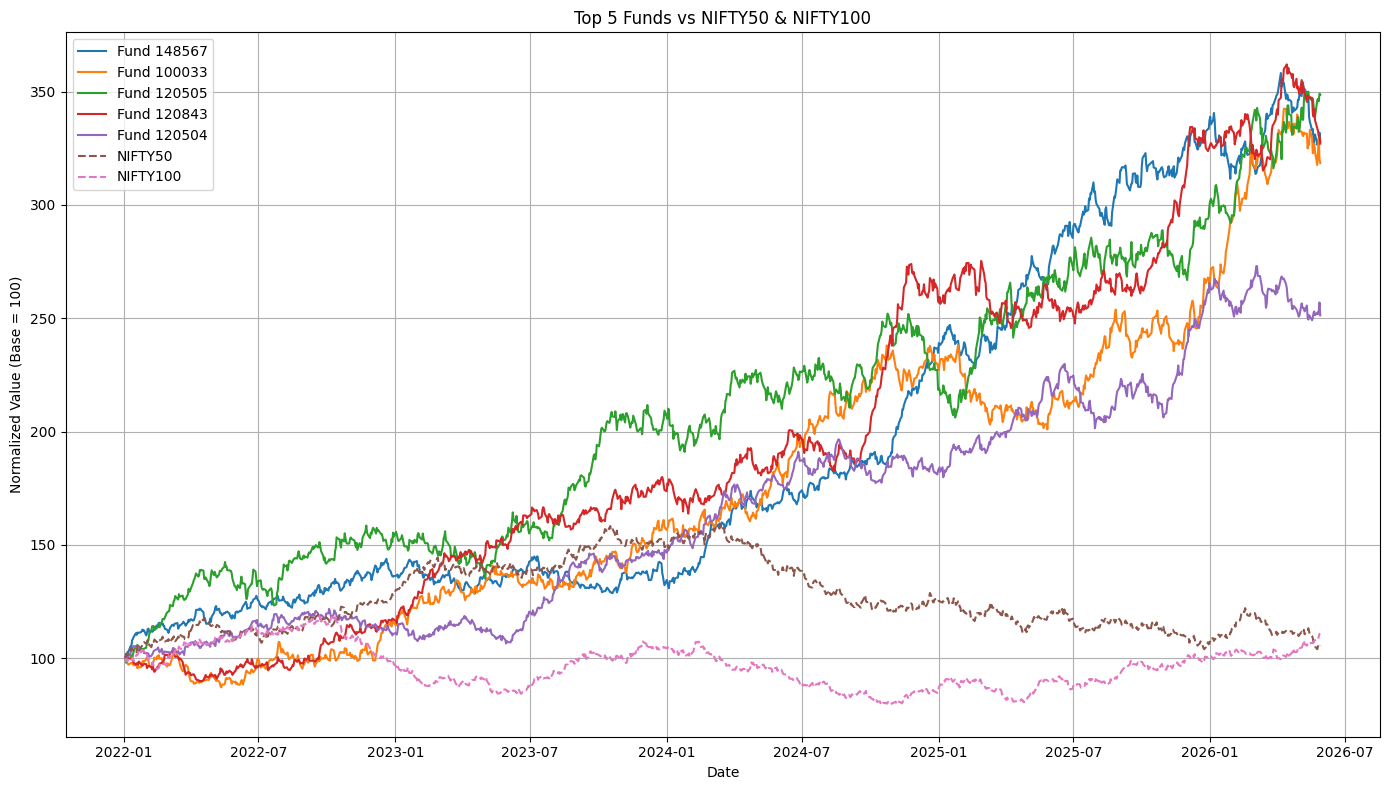

In [89]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,8))

for fund in top5_codes:

    temp = top5_nav[top5_nav['amfi_code'] == fund].copy()

    temp = temp.sort_values('date')

    plt.plot(
        temp['date'],
        temp['normalized'],
        label=f'Fund {fund}'
    )

for idx in ['NIFTY50', 'NIFTY100']:

    temp = benchmarks[
        benchmarks['index_name'] == idx
    ].copy()

    temp = temp.sort_values('date')

    plt.plot(
        temp['date'],
        temp['normalized'],
        linestyle='--',
        label=idx
    )

plt.title('Top 5 Funds vs NIFTY50 & NIFTY100')
plt.xlabel('Date')
plt.ylabel('Normalized Value (Base = 100)')
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.show()

In [90]:
plt.close('all')

In [91]:
plt.savefig(
    "../outputs/benchmark_comparison.png",
    dpi=300,
    bbox_inches='tight'
)

<Figure size 640x480 with 0 Axes>

In [92]:
top5_nav['date'].dtype

dtype('<M8[us]')

In [93]:
top5_nav.shape

(5750, 5)

In [94]:
benchmarks.shape

(2300, 4)

In [95]:
top5_nav.columns

Index(['amfi_code', 'date', 'nav', 'daily_return', 'normalized'], dtype='str')

In [96]:
benchmarks.columns

Index(['date', 'index_name', 'close_value', 'normalized'], dtype='str')

In [97]:
top5_nav[top5_nav['amfi_code'] == 148567].head()

,amfi_code,date,nav,daily_return,normalized
39100,148567,2022-01-03,70.2514,NaN,100.000000
39101,148567,2022-01-04,71.6085,0.019318,101.931776
39102,148567,2022-01-05,71.3264,-0.003939,101.530219
39103,148567,2022-01-06,72.1746,0.011892,102.737597
39104,148567,2022-01-07,72.2118,0.000515,102.790549


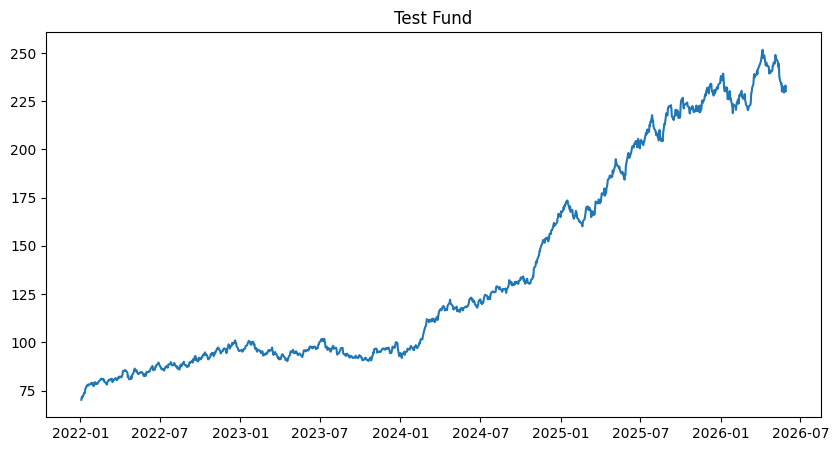

In [98]:
import matplotlib.pyplot as plt

temp = top5_nav[top5_nav['amfi_code'] == 148567]

plt.figure(figsize=(10,5))
plt.plot(temp['date'], temp['nav'])
plt.title("Test Fund")
plt.show()

In [100]:
import os

os.listdir("../outputs")

['alpha_beta.csv',
 'benchmark_comparison.png',
 'fund_scorecard.csv',
 'max_drawdown.csv']